In [76]:
# Fraud Detection using PaySim Dataset
# Exploratory Data Analysis (EDA)

# This notebook explores the PaySim dataset to understand
# transaction patterns and fraudulent activity before model training.

In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [78]:
df = pd.read_csv("/content/PaySim - Synthetic Financial Dataset for Fraud Detection.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [79]:
# shape
df.shape

(6362620, 11)

In [80]:
# columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [81]:
# datatypes
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [82]:
# statistical summary
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [83]:
df.isnull().sum() # Missing values

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [84]:
import os

folders = [
    "../images/fraud_distribution",
    "../images/transaction_types",
    "../images/fraud_by_transaction_type",
    "../images/transaction_amount_distribution",
    "../images/correlation_heatmap"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

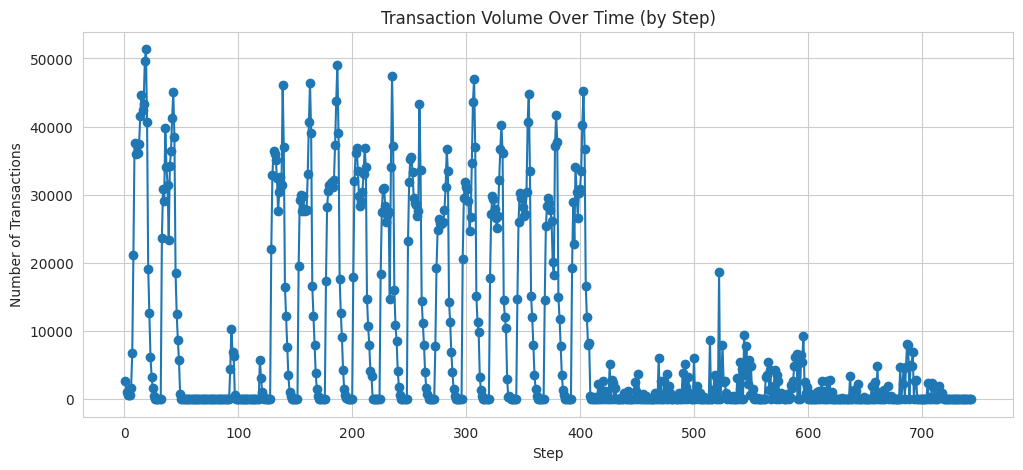

In [86]:
# Transaction Volume Over Time
# Concept: Detect seasonal or temporal trends in transaction activity. Sudden spikes may indicate fraud bursts.
# Technical Insight: Use time-series aggregation of transaction counts by day/week/month.

# The 'transaction_date' column does not exist. Using 'step' as a proxy for time.
time_series = df.groupby('step').size()

plt.figure(figsize=(12,5))
plt.plot(time_series, marker='o')
plt.title('Transaction Volume Over Time (by Step)')
plt.xlabel('Step')
plt.ylabel('Number of Transactions')
plt.savefig("../images/transaction_volume_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

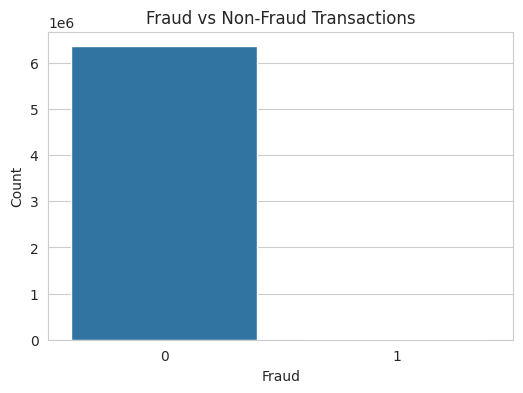

In [87]:
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.savefig("../images/fraud_distribution/fraud_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

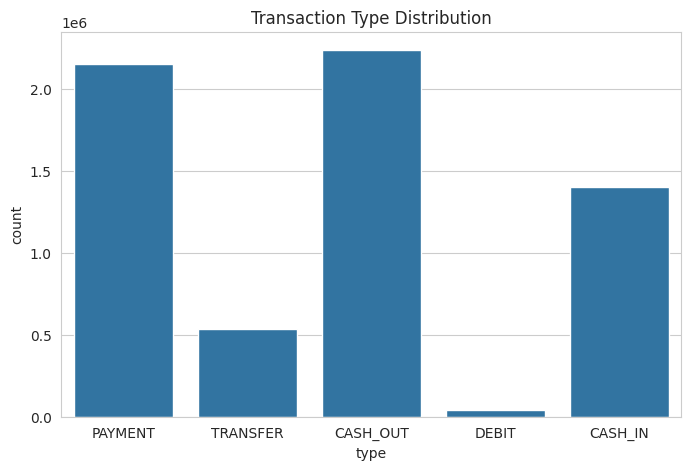

In [88]:
plt.figure(figsize=(8,5))

sns.countplot(x="type", data=df)

plt.title("Transaction Type Distribution")

plt.savefig("../images/transaction_types/transaction_types.png", dpi=300, bbox_inches="tight")

plt.show()

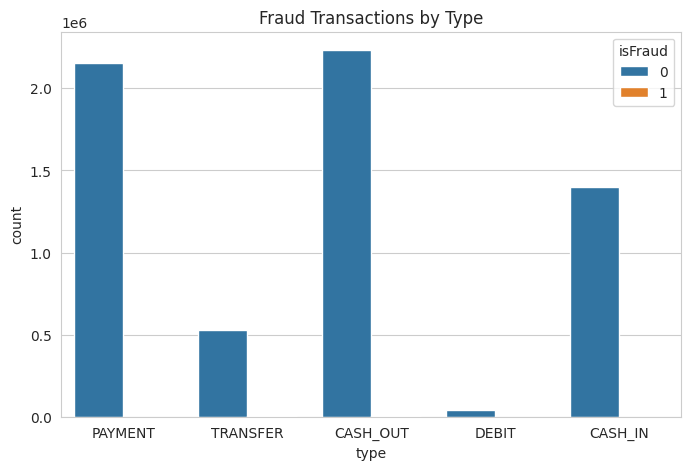

In [89]:
plt.figure(figsize=(8,5))

sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud Transactions by Type")

plt.savefig("../images/fraud_by_transaction_type/fraud_by_transaction_type.png", dpi=300, bbox_inches="tight")

plt.show()

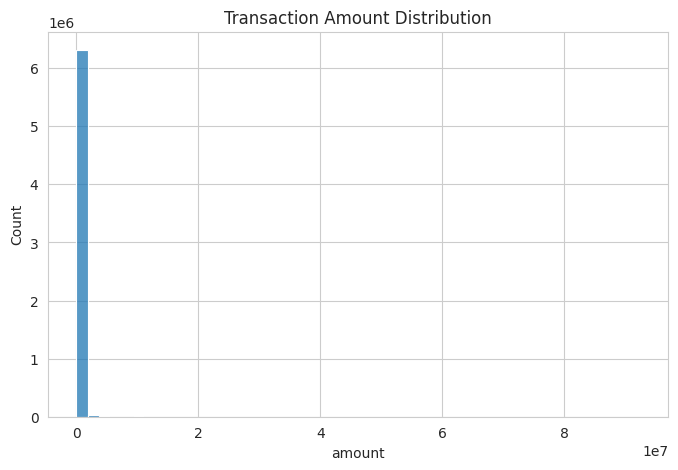

In [90]:
# Visualizing transaction amount distribution helps understand
# skewness and the need for feature scaling.

plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.savefig("../images/transaction_amount_distribution/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

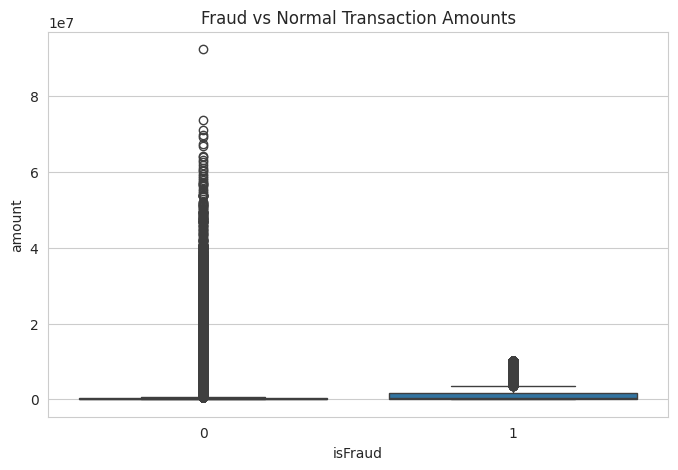

In [91]:
plt.figure(figsize=(8,5))

sns.boxplot(x="isFraud", y="amount", data=df)

plt.title("Fraud vs Normal Transaction Amounts")

plt.savefig("../images/transaction_types/fraud_vs_normal_transaction_amounts.png", dpi=300, bbox_inches="tight")

plt.show()

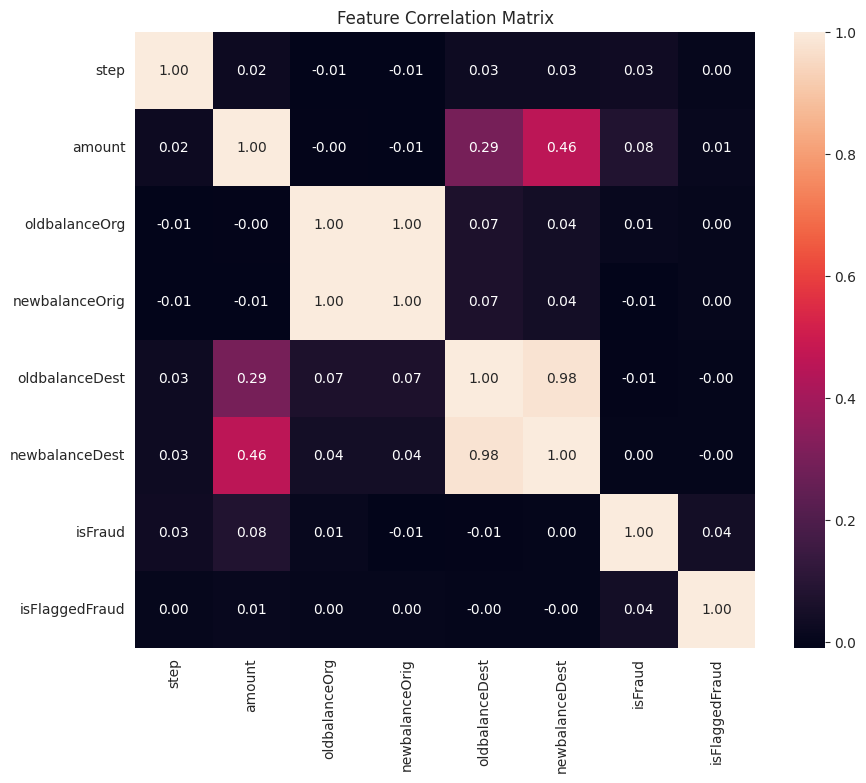

In [94]:
plt.figure(figsize=(10,8))

numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), cmap="rocket", annot=True, fmt=".2f")

plt.title("Feature Correlation Matrix")

plt.savefig("../images/correlation_heatmap/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

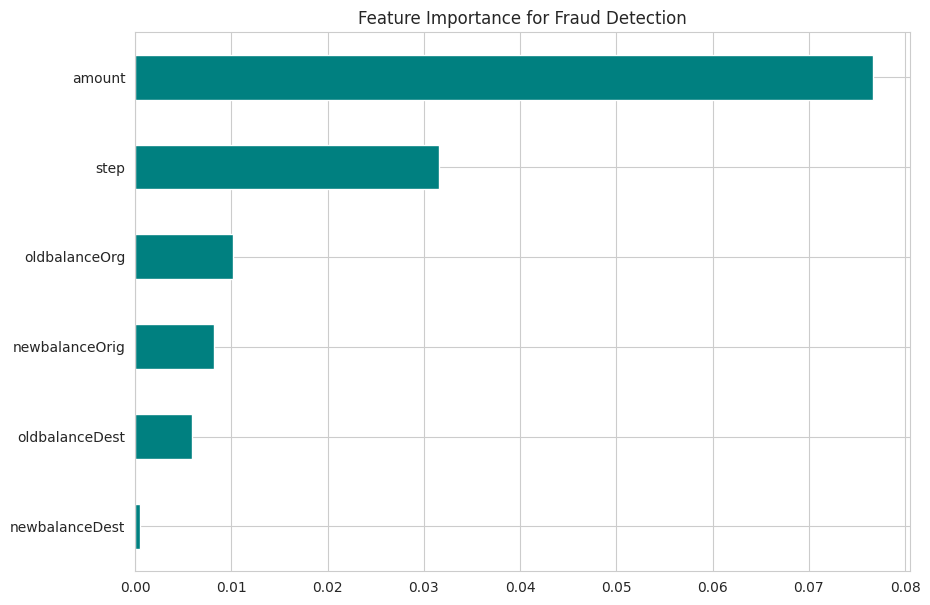

In [96]:
# Feature Importance using Correlation (No ML model needed)

# Select only numerical features for correlation calculation
features = df.drop(columns=['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']).select_dtypes(include=[np.number])

importances = features.corrwith(df['isFraud']).abs().sort_values()

importances.plot(kind='barh', figsize=(10, 7), color='teal')
plt.title('Feature Importance for Fraud Detection')
lt.savefig("../images/transaction_types/feature_importance.png", dpi=300, bbox_inches="tight")p
plt.show()

In [97]:
fraud_percentage = df["isFraud"].value_counts(normalize=True) * 100

fraud_percentage

,proportion
isFraud,
0,99.870918
1,0.129082


In [98]:
fraud = df[df["isFraud"] == 1]
normal = df[df["isFraud"] == 0]

print("Average Fraud Amount:", fraud["amount"].mean())
print("Average Normal Amount:", normal["amount"].mean())

Average Fraud Amount: 1467967.299140387
Average Normal Amount: 178197.04172740763


In [99]:
import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, "processed_paysim.csv"), index=False)